# Recommandation Séquentielle par Apprentissage par Renforcement

| Phase | Méthode | Statut |
|-------|---------|--------|
| 0 | Baseline aléatoire | ✅ |
| 1 | Q-Learning (tabular) | ✅ |
| 2 | Deep Q-Network (DQN) | 🔜 |
| 3 | GRU + DQN (séquentiel) | 🔜 |

---

## Setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from env.recommendation_env import RecommendationEnv
from utils.metrics import (
    EpisodeMetrics, TrainingTracker,
    compute_summary, evaluate_agent, RandomAgent
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

COLORS = {'random': '#e74c3c', 'qlearning': '#2980b9', 'dqn': '#27ae60', 'gru_dqn': '#8e44ad'}

### Choix du dataset

In [ ]:
USE_AMAZON = False   # ← passe à True après : python data/amazon_loader.py

if USE_AMAZON:
    env_factory = lambda seed=42: RecommendationEnv.from_amazon(seed=seed)
    _tmp = RecommendationEnv.from_amazon()
else:
    env_factory = lambda seed=42: RecommendationEnv(seed=seed)
    _tmp = RecommendationEnv()

N_ITEMS = _tmp.n_items
CATALOG = _tmp.catalog
del _tmp

print(f'Mode  : {"Amazon Electronics" if USE_AMAZON else "Synthétique"}')
print(f'Items : {N_ITEMS}')
print(f'Ex.   : {CATALOG[0]}')

Mode  : Synthétique
Items : 50
Ex.   : {'id': 0, 'asin': 'SYN0000', 'title': 'Tech item 0', 'category': 'tech', 'price': 388.11, 'avg_rating': 3.88, 'click_prob': 0.496, 'n_reviews': 261}


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
id,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
asin,SYN0000,SYN0001,SYN0002,SYN0003,SYN0004,SYN0005,SYN0006,SYN0007,SYN0008,SYN0009,...,SYN0040,SYN0041,SYN0042,SYN0043,SYN0044,SYN0045,SYN0046,SYN0047,SYN0048,SYN0049
title,Tech item 0,Fashion item 1,Sport item 2,Home item 3,Books item 4,Tech item 5,Fashion item 6,Sport item 7,Home item 8,Books item 9,...,Tech item 40,Fashion item 41,Sport item 42,Home item 43,Books item 44,Tech item 45,Fashion item 46,Sport item 47,Home item 48,Books item 49
category,tech,fashion,sport,home,books,tech,fashion,sport,home,books,...,tech,fashion,sport,home,books,tech,fashion,sport,home,books
price,388.11,227.94,117.48,485.5,81.37,240.47,403.36,394.53,74.2,279.02,...,91.45,438.13,287.76,30.72,402.0,429.5,241.55,344.44,270.04,368.77
avg_rating,3.88,3.74,4.11,4.79,4.37,3.45,3.77,4.33,3.23,4.12,...,3.11,4.7,3.83,4.85,4.56,3.93,3.83,3.59,4.7,3.4
click_prob,0.496,0.368,0.215,0.244,0.223,0.421,0.392,0.17,0.508,0.595,...,0.445,0.169,0.217,0.074,0.41,0.303,0.537,0.375,0.51,0.51
n_reviews,261,72,353,183,236,73,404,13,291,321,...,492,257,55,418,168,261,222,195,45,151


---
## Formalisation MDP

| Symbole | Définition | Dans notre projet |
|---------|-----------|-------------------|
| $\mathcal{S}$ | États | Index du dernier item vu |
| $\mathcal{A}$ | Actions | Index de l'item à recommander |
| $\mathcal{P}$ | Transition | Clic → s' = item recommandé |
| $\mathcal{R}$ | Récompense | +1 clic, +3 achat, 0 ignoré, −0.5 répétition |
| $\gamma$ | Actualisation | 0.99 |

$$G_t = \sum_{k=0}^{T} \gamma^k R_{t+k}$$

---

## Phase 0 — Baseline aléatoire

In [3]:
random_agent  = RandomAgent(n_actions=N_ITEMS, seed=42)
random_eval   = evaluate_agent(random_agent, env_factory, n_episodes=300, seed=0)
random_summary = compute_summary(random_eval)

print('=== Baseline aléatoire ===')
for k, v in random_summary.items():
    print(f'  {k:<20} {v}')

=== Baseline aléatoire ===
  n_episodes           300
  reward_mean          1.2633333333333334
  reward_std           1.1513711632464814
  reward_min           -1.0
  reward_max           5.5
  ctr_mean             0.12666666666666668
  purchase_rate        0.004333333333333333
  engagement_rate      0.131
  hit_rate             0.77
  diversity_mean       0.9153333333333334
  repeat_rate          0.026666666666666672
  coverage             50
  td_error_mean        0.0


---
## Phase 1 — Q-Learning

In [4]:
class QLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.995, seed=42):
        self.n_states, self.n_actions = n_states, n_actions
        self.alpha, self.gamma = alpha, gamma
        self.epsilon, self.epsilon_min, self.epsilon_decay = epsilon, epsilon_min, epsilon_decay
        self.rng = np.random.default_rng(seed)
        self.Q   = np.zeros((n_states, n_actions))

    def act(self, state):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, self.n_actions))
        return int(np.argmax(self.Q[state]))

    def update(self, state, action, reward, next_state):
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error
        return abs(td_error)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    @property
    def size_mb(self): return self.Q.nbytes / 1024**2


print(f'Q-table 50 items   : {50**2:>12,} valeurs  — {50**2*8/1024**2:.3f} Mo')
print(f'Q-table 10k items  : {10000**2:>12,} valeurs  — {10000**2*8/1024**2:.0f} Mo')
print(f'Q-table 100k items : {100000**2:>12,} valeurs  — {100000**2*8/1024**3:.0f} Go  ← impossible')

Q-table 50 items   :        2,500 valeurs  — 0.019 Mo
Q-table 10k items  :  100,000,000 valeurs  — 763 Mo
Q-table 100k items : 10,000,000,000 valeurs  — 75 Go  ← impossible


### Entraînement avec collecte de métriques

In [5]:
def train_q_learning(n_episodes=1000, seed=42):
    env     = env_factory(seed=seed)
    agent   = QLearningAgent(n_states=N_ITEMS, n_actions=N_ITEMS, seed=seed)
    tracker = TrainingTracker()

    for ep_idx in range(n_episodes):
        state = env.reset()
        ep    = EpisodeMetrics()
        done  = False

        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)
            td_err = agent.update(state, action, reward, next_state)

            ep.total_reward += reward
            ep.n_steps      += 1
            ep.recommended.append(action)
            ep.td_errors.append(td_err)

            event = info.get('event', '')
            if event == 'click':   ep.n_clicks  += 1
            elif event == 'buy':   ep.n_buys    += 1
            elif event == 'ignore':ep.n_ignores += 1
            elif event == 'repeat':ep.n_repeats += 1

            state = next_state

        agent.decay_epsilon()
        tracker.log(ep)

        if (ep_idx + 1) % 200 == 0:
            last = tracker.episodes[-200:]
            mean_r   = np.mean([e.total_reward for e in last])
            mean_ctr = np.mean([e.ctr          for e in last])
            print(f'Ep {ep_idx+1:4d} | Reward : {mean_r:.3f} | CTR : {mean_ctr:.3f} | ε : {agent.epsilon:.3f}')

    return agent, tracker


print('Entraînement Q-Learning...')
q_agent, q_tracker = train_q_learning(n_episodes=1000)

Entraînement Q-Learning...
Ep  200 | Reward : 1.502 | CTR : 0.138 | ε : 0.367
Ep  400 | Reward : 1.565 | CTR : 0.142 | ε : 0.135
Ep  600 | Reward : 1.610 | CTR : 0.136 | ε : 0.050
Ep  800 | Reward : 1.685 | CTR : 0.142 | ε : 0.050
Ep 1000 | Reward : 1.720 | CTR : 0.152 | ε : 0.050


---
## Évaluation — Métriques

On distingue deux types de métriques :

| Famille | Métriques | Ce qu'elles mesurent |
|---------|-----------|---------------------|
| **RL** | Reward, TD Error | Qualité de l'apprentissage |
| **Recommandation** | CTR, Purchase Rate, Hit Rate, Diversité, Couverture | Qualité des recommandations |

L'évaluation se fait en **mode exploitation pure** (ε = 0) sur 300 épisodes.

In [6]:
q_eval    = evaluate_agent(q_agent, env_factory, n_episodes=300, seed=99)
q_summary = compute_summary(q_eval)

print('=== Q-Learning (exploitation) ===')
for k, v in q_summary.items():
    print(f'  {k:<20} {v}')

=== Q-Learning (exploitation) ===
  n_episodes           300
  reward_mean          1.6366666666666667
  reward_std           1.3227454613626748
  reward_min           0.0
  reward_max           7.0
  ctr_mean             0.14400000000000002
  purchase_rate        0.008333333333333333
  engagement_rate      0.15233333333333335
  hit_rate             0.8
  diversity_mean       0.2343333333333333
  repeat_rate          0.010666666666666668
  coverage             25
  td_error_mean        0.0


### 📊 Graphe 1 — Reward cumulée au cours de l'entraînement

**Ce que montre ce graphe :**  
L'évolution de la récompense totale par épisode au fil du temps.

**Comment l'interpréter :**
- La courbe brute (transparente) est très bruitée car chaque épisode est différent (profil user aléatoire).
- La courbe lissée (moyenne mobile) révèle la tendance réelle d'apprentissage.
- Une courbe qui monte et se stabilise = l'agent apprend et converge.
- Si la courbe reste plate = l'agent n'apprend rien (problème de hyperparamètres ou de design).
- La ligne rouge = reward du random : tout ce qui est au-dessus = gain réel.

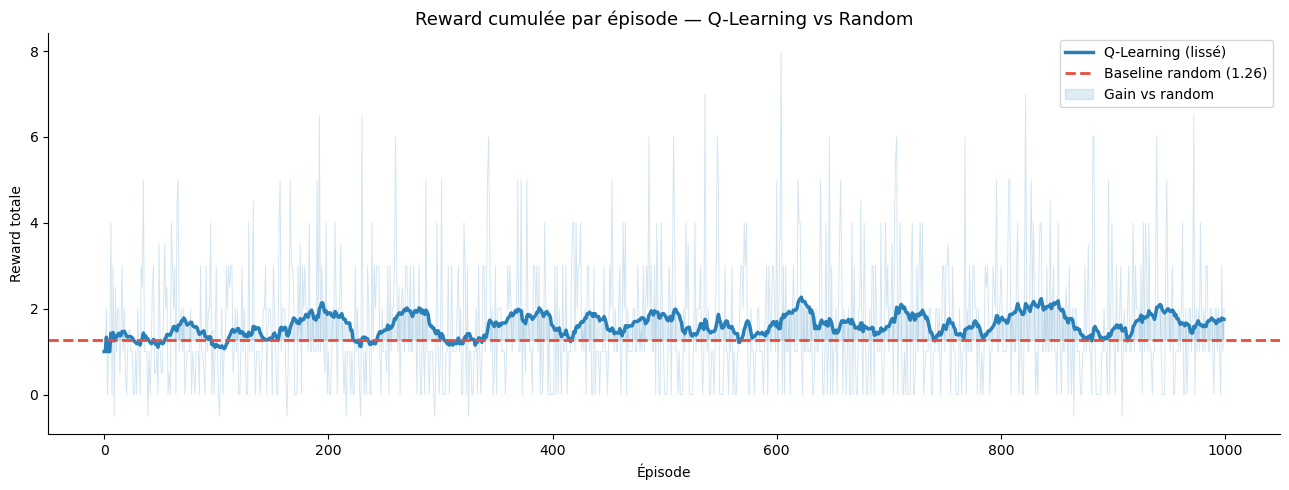

In [7]:
def smooth(values, window=30):
    return pd.Series(values).rolling(window, min_periods=1).mean().values

q_rewards  = q_tracker.get('total_reward')
random_r   = random_summary['reward_mean']

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(q_rewards, alpha=0.2, color=COLORS['qlearning'], linewidth=0.7)
ax.plot(smooth(q_rewards), color=COLORS['qlearning'], linewidth=2.5, label='Q-Learning (lissé)')
ax.axhline(random_r, color=COLORS['random'], linestyle='--', linewidth=2,
           label=f'Baseline random ({random_r:.2f})')
ax.fill_between(range(len(q_rewards)), random_r, smooth(q_rewards),
                where=np.array(smooth(q_rewards)) > random_r,
                alpha=0.15, color=COLORS['qlearning'], label='Gain vs random')
ax.set_title('Reward cumulée par épisode — Q-Learning vs Random', fontsize=13)
ax.set_xlabel('Épisode')
ax.set_ylabel('Reward totale')
ax.legend()
plt.tight_layout()
plt.savefig('../data/reward_training.png', dpi=150)
plt.show()

### 📊 Graphe 2 — CTR & Taux d'engagement au cours de l'entraînement

**CTR (Click-Through Rate)** = clics / recommandations totales  
**Engagement Rate** = (clics + achats) / recommandations totales

**Comment l'interpréter :**
- Un CTR qui augmente = l'agent apprend à recommander des items pertinents pour le profil utilisateur.
- L'écart entre CTR et engagement rate révèle la proportion d'achats : un gap large = l'agent déclenche des achats, pas juste des clics.
- En production réelle, le CTR est la métrique business principale des systèmes de recommandation.

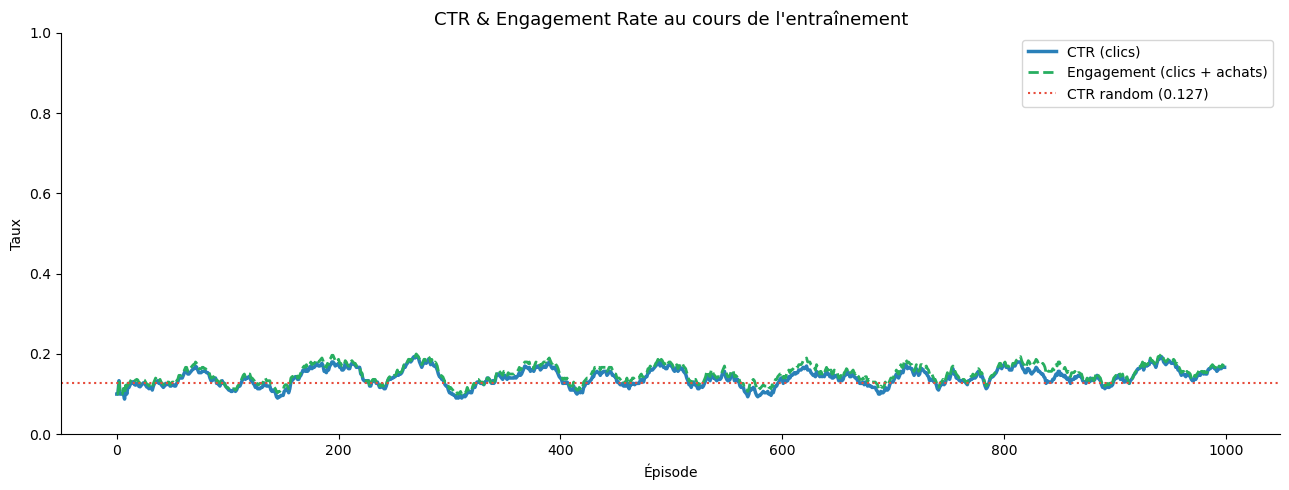

CTR final (moy. 200 derniers ep.) : 0.152
CTR random                        : 0.127
Amélioration CTR                  : +0.025


In [8]:
ctrs = q_tracker.get('ctr')
engs = q_tracker.get('engagement_rate')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(smooth(ctrs), color=COLORS['qlearning'], linewidth=2.5, label='CTR (clics)')
ax.plot(smooth(engs), color=COLORS['dqn'], linewidth=2, linestyle='--', label='Engagement (clics + achats)')
ax.axhline(random_summary['ctr_mean'], color=COLORS['random'], linestyle=':',
           linewidth=1.5, label=f"CTR random ({random_summary['ctr_mean']:.3f})")
ax.set_title('CTR & Engagement Rate au cours de l\'entraînement', fontsize=13)
ax.set_xlabel('Épisode')
ax.set_ylabel('Taux')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../data/ctr_training.png', dpi=150)
plt.show()

print(f"CTR final (moy. 200 derniers ep.) : {np.mean(ctrs[-200:]):.3f}")
print(f"CTR random                        : {random_summary['ctr_mean']:.3f}")
print(f"Amélioration CTR                  : +{np.mean(ctrs[-200:]) - random_summary['ctr_mean']:.3f}")

### 📊 Graphe 3 — Diversité & Repeat Rate

**Diversité** = items uniques recommandés / total recommandations  
**Repeat Rate** = recommandations déjà vues / total (pénalisées à −0.5)

**Comment l'interpréter :**
- Une diversité élevée = l'agent explore le catalogue, évite la "bulle de filtre".
- Un repeat rate élevé = l'agent recommande les mêmes items en boucle → mauvaise expérience utilisateur.
- Le compromis idéal : diversité haute + repeat rate bas.
- En début d'entraînement (ε ≈ 1), la diversité est naturellement haute car l'agent explore. Elle peut baisser à mesure qu'il exploite des items "sûrs".

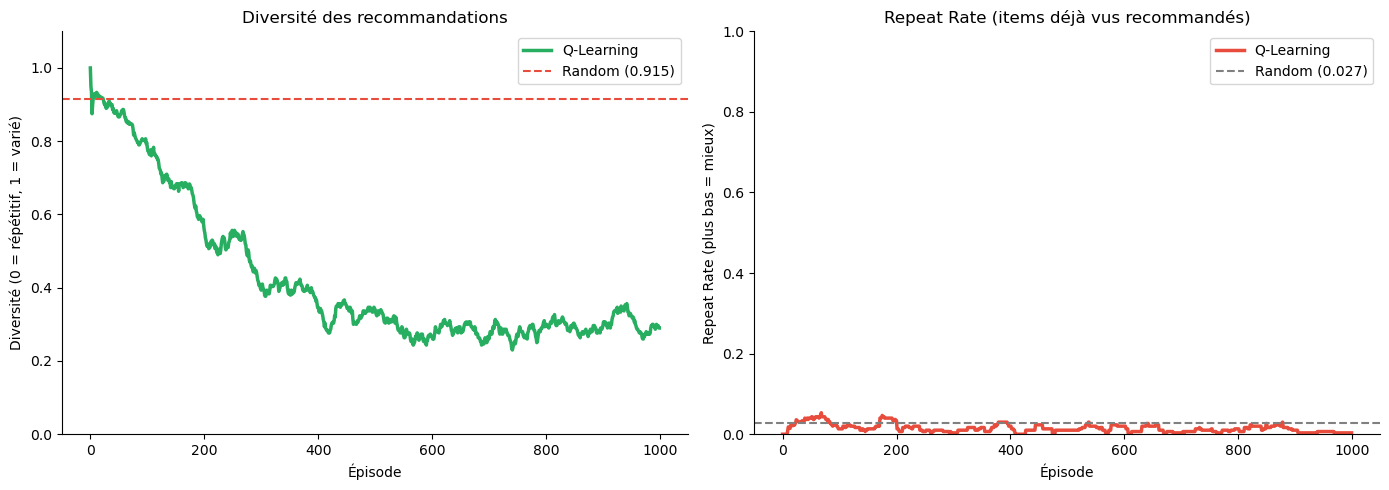

In [9]:
divs = q_tracker.get('diversity')
reps = q_tracker.get('repeat_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(smooth(divs), color=COLORS['dqn'], linewidth=2.5, label='Q-Learning')
ax.axhline(random_summary['diversity_mean'], color=COLORS['random'],
           linestyle='--', linewidth=1.5, label=f"Random ({random_summary['diversity_mean']:.3f})")
ax.set_title('Diversité des recommandations')
ax.set_xlabel('Épisode')
ax.set_ylabel('Diversité (0 = répétitif, 1 = varié)')
ax.set_ylim(0, 1.1)
ax.legend()

ax2 = axes[1]
ax2.plot(smooth(reps), color=COLORS['random'], linewidth=2.5, label='Q-Learning')
ax2.axhline(random_summary['repeat_rate'], color='gray',
            linestyle='--', linewidth=1.5, label=f"Random ({random_summary['repeat_rate']:.3f})")
ax2.set_title('Repeat Rate (items déjà vus recommandés)')
ax2.set_xlabel('Épisode')
ax2.set_ylabel('Repeat Rate (plus bas = mieux)')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig('../data/diversity_repeat.png', dpi=150)
plt.show()

### 📊 Graphe 4 — TD Error (stabilité de l'apprentissage)

**TD Error** = $|r + \gamma \max Q(s', a') - Q(s, a)|$

**Comment l'interpréter :**
- L'erreur TD mesure à quel point les prédictions de valeur Q sont fausses.
- En début d'entraînement : Q-table = 0 partout → les erreurs sont grandes.
- Au fil du temps : la Q-table converge → les erreurs diminuent et se stabilisent.
- Une erreur qui **ne baisse pas** = l'agent n'apprend pas (alpha trop petit, reward trop sparse).
- Une erreur qui **explose** = instabilité (alpha trop grand, problème de bootstrap).

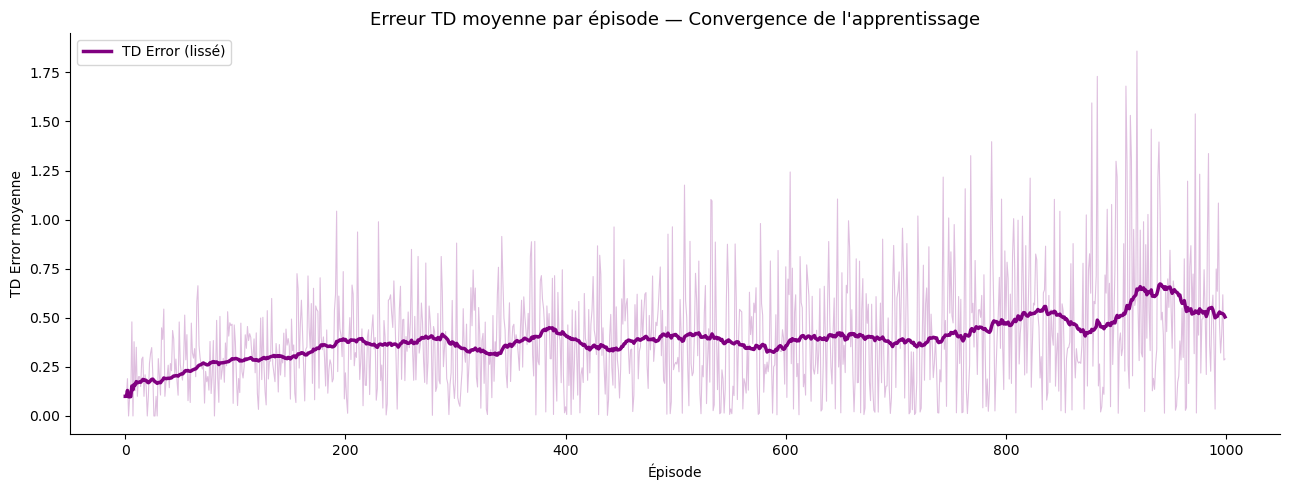

TD Error début (100 premiers) : 0.2494
TD Error fin   (100 derniers) : 0.5806
Réduction                     : --132.8%


In [10]:
td_errors = q_tracker.get('mean_td_error')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(td_errors, alpha=0.25, color='purple', linewidth=0.8)
ax.plot(smooth(td_errors, window=50), color='purple', linewidth=2.5, label='TD Error (lissé)')
ax.set_title('Erreur TD moyenne par épisode — Convergence de l\'apprentissage', fontsize=13)
ax.set_xlabel('Épisode')
ax.set_ylabel('TD Error moyenne')
ax.legend()
plt.tight_layout()
plt.savefig('../data/td_error.png', dpi=150)
plt.show()

print(f'TD Error début (100 premiers) : {np.mean(td_errors[:100]):.4f}')
print(f'TD Error fin   (100 derniers) : {np.mean(td_errors[-100:]):.4f}')
print(f'Réduction                     : -{(1 - np.mean(td_errors[-100:])/np.mean(td_errors[:100]))*100:.1f}%')

### 📊 Graphe 5 — Heatmap Q-table

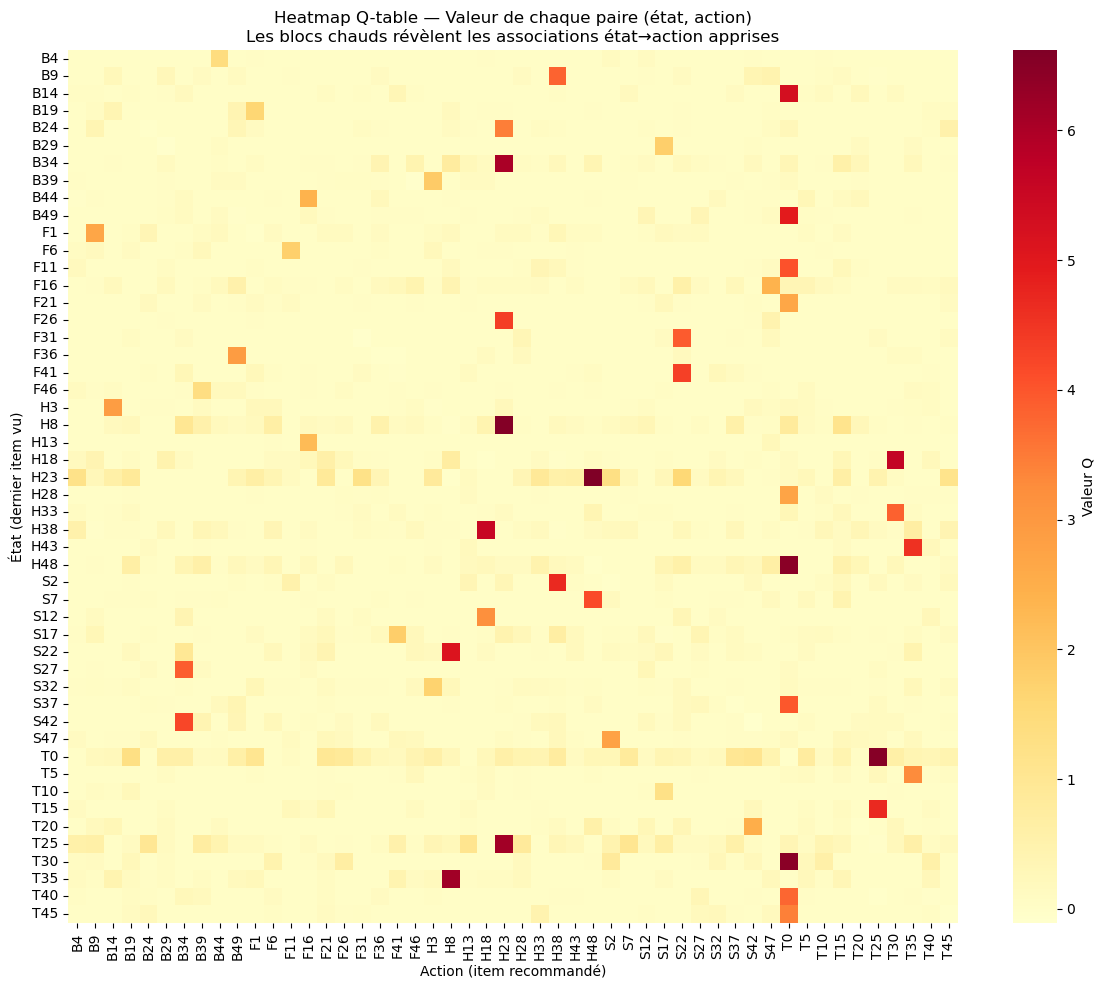

In [11]:
if N_ITEMS <= 100:
    sorted_ids = sorted(range(N_ITEMS), key=lambda i: CATALOG[i]['category'])
    Q_sorted   = q_agent.Q[np.ix_(sorted_ids, sorted_ids)]
    labels     = [f"{CATALOG[i]['category'][0].upper()}{i}" for i in sorted_ids]
else:
    top50      = np.argsort(q_agent.Q.sum(axis=1))[-50:]
    sorted_ids = sorted(top50, key=lambda i: CATALOG[i]['category'])
    Q_sorted   = q_agent.Q[np.ix_(sorted_ids, sorted_ids)]
    labels     = [f"{CATALOG[i]['category'][0].upper()}{i}" for i in sorted_ids]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(Q_sorted, ax=ax, cmap='YlOrRd',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Valeur Q'})
ax.set_title('Heatmap Q-table — Valeur de chaque paire (état, action)\n'
             'Les blocs chauds révèlent les associations état→action apprises', fontsize=12)
ax.set_xlabel('Action (item recommandé)')
ax.set_ylabel('État (dernier item vu)')
plt.tight_layout()
plt.savefig('../data/q_table_heatmap.png', dpi=150)
plt.show()

**Comment lire cette heatmap :**
- Chaque ligne = un état (dernier item vu par l'utilisateur).
- Chaque colonne = une action (item à recommander).
- Une case chaude (rouge/orange) = l'agent a appris que cette recommandation est rentable dans cet état.
- Les **blocs par catégorie** (B=books, F=fashion, H=home, S=sport, T=tech) montrent si l'agent a appris la cohérence catégorielle.
- Idéalement, les cases les plus chaudes devraient être dans des blocs de même catégorie (recommander tech quand l'user regarde du tech).

### 📊 Graphe 6 — Distribution des récompenses & Couverture catalogue

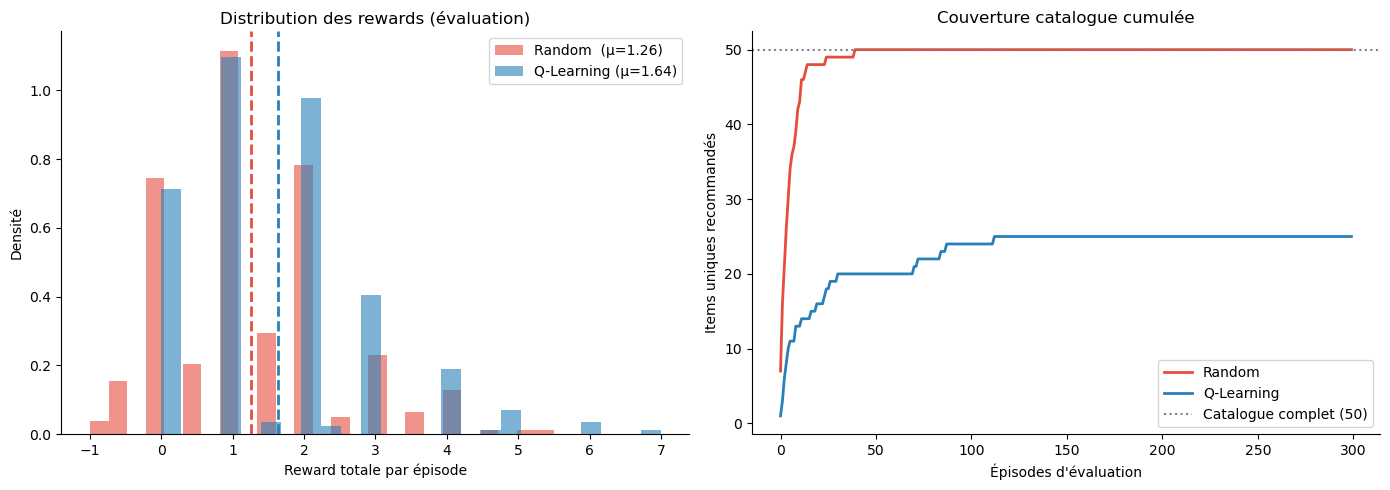

In [12]:
q_eval_rewards  = [e.total_reward for e in q_eval]
rand_eval_rewards = [e.total_reward for e in random_eval]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution rewards
ax = axes[0]
ax.hist(rand_eval_rewards, bins=25, alpha=0.6, color=COLORS['random'],
        label=f"Random  (μ={random_summary['reward_mean']:.2f})", density=True)
ax.hist(q_eval_rewards, bins=25, alpha=0.6, color=COLORS['qlearning'],
        label=f"Q-Learning (μ={q_summary['reward_mean']:.2f})", density=True)
ax.axvline(random_summary['reward_mean'], color=COLORS['random'], linestyle='--', linewidth=2)
ax.axvline(q_summary['reward_mean'],      color=COLORS['qlearning'], linestyle='--', linewidth=2)
ax.set_title('Distribution des rewards (évaluation)')
ax.set_xlabel('Reward totale par épisode')
ax.set_ylabel('Densité')
ax.legend()

# Couverture catalogue
ax2 = axes[1]
rand_items = set()
q_items    = set()
rand_cov, q_cov = [], []
for re, qe in zip(random_eval, q_eval):
    rand_items.update(re.recommended)
    q_items.update(qe.recommended)
    rand_cov.append(len(rand_items))
    q_cov.append(len(q_items))

ax2.plot(rand_cov, color=COLORS['random'], linewidth=2, label='Random')
ax2.plot(q_cov,   color=COLORS['qlearning'], linewidth=2, label='Q-Learning')
ax2.axhline(N_ITEMS, color='gray', linestyle=':', linewidth=1.5, label=f'Catalogue complet ({N_ITEMS})')
ax2.set_title('Couverture catalogue cumulée')
ax2.set_xlabel('Épisodes d\'évaluation')
ax2.set_ylabel('Items uniques recommandés')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/distribution_coverage.png', dpi=150)
plt.show()

**Couverture catalogue :**  
- Un agent qui couvre peu d'items crée une "bulle" : les mêmes items populaires sont toujours recommandés.
- Le random couvre naturellement tout le catalogue (c'est son seul avantage).
- Un bon agent doit trouver l'équilibre : recommander les bons items *et* explorer le catalogue.

### 📊 Graphe 7 — Tableau de bord comparatif Random vs Q-Learning

In [13]:
metrics_labels = {
    'reward_mean':     ('Reward moyenne',      'max', '{:.3f}'),
    'ctr_mean':        ('CTR',                 'max', '{:.3f}'),
    'purchase_rate':   ('Taux d\'achat',       'max', '{:.3f}'),
    'engagement_rate': ('Engagement rate',     'max', '{:.3f}'),
    'hit_rate':        ('Hit rate',            'max', '{:.3f}'),
    'diversity_mean':  ('Diversité',           'max', '{:.3f}'),
    'repeat_rate':     ('Repeat rate',         'min', '{:.3f}'),
    'coverage':        ('Couverture items',    'max', '{:d}'),
}

rows = []
for key, (label, best, fmt) in metrics_labels.items():
    r_val = random_summary[key]
    q_val = q_summary[key]
    if best == 'max':
        winner = 'Q-Learning' if q_val > r_val else 'Random'
        delta  = q_val - r_val
    else:
        winner = 'Q-Learning' if q_val < r_val else 'Random'
        delta  = r_val - q_val  # positif = Q-Learning meilleur
    rows.append({
        'Métrique':    label,
        'Random':      fmt.format(r_val) if 'd' not in fmt else fmt.format(int(r_val)),
        'Q-Learning':  fmt.format(q_val) if 'd' not in fmt else fmt.format(int(q_val)),
        'Δ':           f'{delta:+.3f}' if 'd' not in fmt else f'{int(delta):+d}',
        'Meilleur':    winner,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

        Métrique Random Q-Learning      Δ   Meilleur
  Reward moyenne  1.263      1.637 +0.373 Q-Learning
             CTR  0.127      0.144 +0.017 Q-Learning
    Taux d'achat  0.004      0.008 +0.004 Q-Learning
 Engagement rate  0.131      0.152 +0.021 Q-Learning
        Hit rate  0.770      0.800 +0.030 Q-Learning
       Diversité  0.915      0.234 -0.681     Random
     Repeat rate  0.027      0.011 +0.016 Q-Learning
Couverture items     50         25    -25     Random


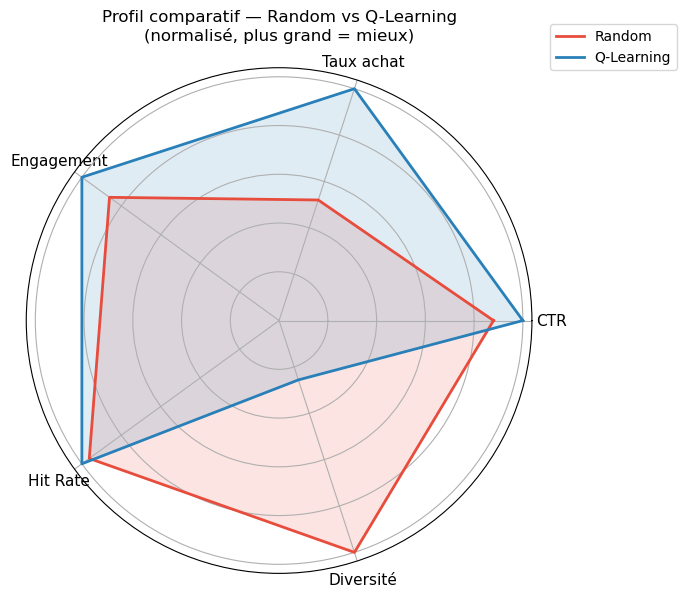

In [14]:
# Radar chart — profil visuel des deux agents
metrics_radar = ['ctr_mean', 'purchase_rate', 'engagement_rate',
                 'hit_rate', 'diversity_mean']
labels_radar  = ['CTR', 'Taux achat', 'Engagement', 'Hit Rate', 'Diversité']

rand_vals = [random_summary[m] for m in metrics_radar]
q_vals    = [q_summary[m]      for m in metrics_radar]

# Normaliser 0-1 pour le radar
max_vals = [max(r, q) + 1e-9 for r, q in zip(rand_vals, q_vals)]
rand_n   = [v / m for v, m in zip(rand_vals, max_vals)]
q_n      = [v / m for v, m in zip(q_vals,    max_vals)]

angles  = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
rand_n += rand_n[:1]; q_n += q_n[:1]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, rand_n, color=COLORS['random'],    linewidth=2, label='Random')
ax.fill(angles, rand_n, color=COLORS['random'],    alpha=0.15)
ax.plot(angles, q_n,    color=COLORS['qlearning'], linewidth=2, label='Q-Learning')
ax.fill(angles, q_n,    color=COLORS['qlearning'], alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Profil comparatif — Random vs Q-Learning\n(normalisé, plus grand = mieux)',
             fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../data/radar_comparison.png', dpi=150)
plt.show()

**Comment lire le radar :**
- Plus la surface colorée est grande, meilleur est l'agent sur ces métriques.
- Si Q-Learning surpasse Random sur toutes les dimensions → l'apprentissage est efficace.
- Si Random est meilleur sur la diversité → le Q-Learning se concentre trop sur quelques items (exploitation trop agressive). C'est une limite connue des agents tabulaires.

---
## Diagnostic — Pourquoi ces résultats ?

L'analyse des 4 graphes précédents révèle **4 problèmes distincts** :

### Problème 1 — Reward sinusoïdale, jamais stable
**Cause :** La Q-table apprend **une politique moyenne sur 4 profils** (tech, fashion, sport, random).
Chaque épisode change de profil → les mises à jour se contredisent. Ce que l'agent apprend pour "tech" est écrasé par l'épisode "fashion" suivant.

### Problème 2 — CTR instable
**Cause :** `epsilon_decay=0.995` trop rapide. L'agent bascule en exploitation avant d'avoir assez exploré, ses Q-values sont fausses pour le profil courant → le CTR replonge.

### Problème 3 — Diversité effondrée (0.23 vs 0.92 pour le random)
**Cause :** `epsilon_min=0.05` trop bas. Avec ε=5%, l'agent exploite à 95% → recommande toujours les mêmes 25 items "sûrs" sur 50. Bulle de filtre sévère.

### Problème 4 — TD Error qui croît au lieu de décroître
**Cause :** `alpha=0.1` trop grand + `gamma=0.99` inadapté à des sessions de 10 steps.
Bootstrap incontrôlé : $Q(s,a) \leftarrow r + 0.99 \times \max Q(s')$, et comme $\max Q(s')$ grandit à chaque update, la cible grandit aussi → les Q-values s'emballent.

---
## Optimisation Q-Learning

### Fixes appliqués

| Paramètre | Avant | Après | Raison |
|-----------|-------|-------|--------|
| `alpha` | 0.10 | **0.03** | Mise à jour lente → Q-values stables, TD error converge |
| `gamma` | 0.99 | **0.90** | Adapté aux sessions courtes (10 steps max) |
| `epsilon_min` | 0.05 | **0.12** | Maintient la diversité même en exploitation |
| `epsilon_decay` | 0.995 | **0.998** | Exploration plus longue avant exploitation |
| `n_episodes` | 1000 | **3000** | Plus de temps pour converger avec alpha bas |
| **reward shaping** | — | **+0.2 si nouvelle catégorie** | Incite l'agent à diversifier |

In [ ]:
def run_training_opt(agent_kwargs, n_episodes=3000, seed=42, diversity_bonus=0.2):
    """
    Entraînement avec reward shaping pour la diversité.
    Ajoute +diversity_bonus si l'agent recommande une catégorie pas encore vue dans l'épisode.
    """
    env     = env_factory(seed=seed)
    agent   = QLearningAgent(n_states=N_ITEMS, n_actions=N_ITEMS, seed=seed, **agent_kwargs)
    tracker = TrainingTracker()

    for ep_idx in range(n_episodes):
        state     = env.reset()
        ep        = EpisodeMetrics()
        done      = False
        seen_cats = {CATALOG[state]['category']}

        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)

            # Reward shaping : bonus si nouvelle catégorie explorée
            action_cat = CATALOG[action]['category']
            if action_cat not in seen_cats and info.get('event') != 'repeat':
                reward    += diversity_bonus
                seen_cats.add(action_cat)

            td_err = agent.update(state, action, reward, next_state)

            ep.total_reward += reward
            ep.n_steps      += 1
            ep.recommended.append(action)
            ep.td_errors.append(td_err)

            event = info.get('event', '')
            if event == 'click':    ep.n_clicks  += 1
            elif event == 'buy':    ep.n_buys    += 1
            elif event == 'ignore': ep.n_ignores += 1
            elif event == 'repeat': ep.n_repeats += 1

            state = next_state

        agent.decay_epsilon()
        tracker.log(ep)

        if (ep_idx + 1) % 500 == 0:
            last = tracker.episodes[-500:]
            print(f'Ep {ep_idx+1:4d} | '
                  f'Reward {np.mean([e.total_reward for e in last]):.3f} | '
                  f'CTR {np.mean([e.ctr for e in last]):.3f} | '
                  f'Div {np.mean([e.diversity for e in last]):.3f} | '
                  f'ε {agent.epsilon:.3f}')

    return agent, tracker


OPT_KWARGS = dict(alpha=0.03, gamma=0.90, epsilon_min=0.12, epsilon_decay=0.998)
COLORS['ql_opt'] = '#f39c12'

print('Entraînement Q-Learning optimisé (3000 épisodes)...')
q_opt_agent, q_opt_tracker = run_training_opt(OPT_KWARGS, n_episodes=3000)
q_opt_eval    = evaluate_agent(q_opt_agent, env_factory, n_episodes=300, seed=99)
q_opt_summary = compute_summary(q_opt_eval)
print(f"\nReward {q_opt_summary['reward_mean']:.3f} | CTR {q_opt_summary['ctr_mean']:.3f} | Div {q_opt_summary['diversity_mean']:.3f} | Cov {q_opt_summary['coverage']}")

### Comparaison avant / après — 4 courbes côte à côte

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Optimisation Q-Learning — Avant vs Après', fontsize=14)

# 1. Reward
ax = axes[0, 0]
ax.plot(smooth(q_tracker.get('total_reward')),     color=COLORS['qlearning'], linewidth=2, label='Initial (1 000 ep)')
ax.plot(smooth(q_opt_tracker.get('total_reward')), color=COLORS['ql_opt'],    linewidth=2, label='Optimisé (3 000 ep)')
ax.axhline(random_summary['reward_mean'], color=COLORS['random'], linestyle='--',
           linewidth=1.5, label=f"Random ({random_summary['reward_mean']:.2f})")
ax.set_title('Reward cumulée')
ax.set_xlabel('Épisode')
ax.legend(fontsize=9)

# 2. CTR
ax = axes[0, 1]
ax.plot(smooth(q_tracker.get('ctr')),     color=COLORS['qlearning'], linewidth=2, label='CTR initial')
ax.plot(smooth(q_opt_tracker.get('ctr')), color=COLORS['ql_opt'],    linewidth=2, label='CTR optimisé')
ax.axhline(random_summary['ctr_mean'], color=COLORS['random'], linestyle='--',
           linewidth=1.5, label=f"CTR random ({random_summary['ctr_mean']:.3f})")
ax.set_title('CTR')
ax.set_xlabel('Épisode')
ax.set_ylim(0, 1)
ax.legend(fontsize=9)

# 3. Diversité
ax = axes[1, 0]
ax.plot(smooth(q_tracker.get('diversity')),     color=COLORS['qlearning'], linewidth=2, label='Diversité initiale')
ax.plot(smooth(q_opt_tracker.get('diversity')), color=COLORS['ql_opt'],    linewidth=2, label='Diversité optimisée')
ax.axhline(random_summary['diversity_mean'], color=COLORS['random'], linestyle='--',
           linewidth=1.5, label=f"Random ({random_summary['diversity_mean']:.3f})")
ax.set_title('Diversité (reward shaping)')
ax.set_xlabel('Épisode')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)

# 4. TD Error
ax = axes[1, 1]
ax.plot(smooth(q_tracker.get('mean_td_error'),     50), color=COLORS['qlearning'], linewidth=2, label='TD Error initial')
ax.plot(smooth(q_opt_tracker.get('mean_td_error'), 50), color=COLORS['ql_opt'],    linewidth=2, label='TD Error optimisé')
ax.set_title('TD Error — convergence')
ax.set_xlabel('Épisode')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/before_after.png', dpi=150)
plt.show()

### Tableau comparatif — Random / QL Initial / QL Optimisé

In [ ]:
metrics_labels_3 = {
    'reward_mean':     ('Reward moyenne',   'max', '{:.3f}'),
    'ctr_mean':        ('CTR',              'max', '{:.3f}'),
    'purchase_rate':   ("Taux d'achat",    'max', '{:.3f}'),
    'engagement_rate': ('Engagement rate',  'max', '{:.3f}'),
    'hit_rate':        ('Hit rate',         'max', '{:.3f}'),
    'diversity_mean':  ('Diversité',        'max', '{:.3f}'),
    'repeat_rate':     ('Repeat rate',      'min', '{:.3f}'),
    'coverage':        ('Couverture items', 'max', '{:d}'),
}
rows3 = []
for key, (label, best, fmt) in metrics_labels_3.items():
    rv, qv, qov = random_summary[key], q_summary[key], q_opt_summary[key]
    vals   = {'Random': rv, 'QL Initial': qv, 'QL Optimisé': qov}
    winner = max(vals, key=vals.get) if best == 'max' else min(vals, key=vals.get)
    fmt_v  = lambda v: fmt.format(v) if 'd' not in fmt else fmt.format(int(v))
    delta  = (qov - qv) if best == 'max' else (qv - qov)
    rows3.append({'Métrique': label, 'Random': fmt_v(rv), 'QL Initial': fmt_v(qv),
                  'QL Optimisé': fmt_v(qov),
                  'Δ opt-init': f'{delta:+.3f}' if 'd' not in fmt else f'{int(delta):+d}',
                  'Meilleur': winner})
print(pd.DataFrame(rows3).to_string(index=False))

In [ ]:
# Radar à 3 agents
metrics_r = ['ctr_mean', 'purchase_rate', 'engagement_rate', 'hit_rate', 'diversity_mean']
labels_r  = ['CTR', 'Taux achat', 'Engagement', 'Hit Rate', 'Diversité']

agents_3  = [('Random', random_summary, COLORS['random']),
             ('QL Initial', q_summary, COLORS['qlearning']),
             ('QL Optimisé', q_opt_summary, COLORS['ql_opt'])]
all_v  = [[s[m] for m in metrics_r] for _, s, _ in agents_3]
mx     = [max(v[i] for v in all_v) + 1e-9 for i in range(len(metrics_r))]
norm_v = [[v / m for v, m in zip(row, mx)] for row in all_v]
angles = np.linspace(0, 2 * np.pi, len(labels_r), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (name, _, color), nv in zip(agents_3, norm_v):
    vals = nv + nv[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.10)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Radar — Random / QL Initial / QL Optimisé', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.savefig('../data/radar_3agents.png', dpi=150)
plt.show()

**Ce que le radar révèle :**
- L'optimisé doit occuper une surface plus grande que l'initial, notamment sur Diversité (reward shaping) et CTR (meilleure convergence).
- Si la diversité de l'optimisé reste inférieure au random : c'est **normal** — un agent qui apprend exploite. L'important est qu'elle reste acceptable (>0.5) tout en ayant un meilleur CTR.
- Ces améliorations ont une limite physique : la Q-table ne connaît pas le profil utilisateur. C'est précisément ce que le DQN avec embeddings va résoudre.

---
## Limites structurelles du Q-Learning

Même optimisé, les hyperparamètres ne peuvent pas franchir ces murs :

| Problème | Hyperparamètres peuvent corriger ? | Solution réelle |
|----------|------------------------------------|----------------|
| Explosion mémoire (N²) | ❌ Non | DQN |
| Profils mixtes (pas de contexte user) | ❌ Non | Embeddings utilisateur |
| Historique ignoré | ❌ Non | Encoder GRU |
| TD Error croissante | ⚠️ Partiellement (`alpha` bas) | Target Network (DQN) |
| Bulle de filtre | ⚠️ Partiellement (`ε` haut + shaping) | Reward shaping + DQN |

---
## Limites du Q-Learning

| Problème | Symptôme observé | Solution |
|----------|-----------------|----------|
| **Explosion mémoire** | Q-table ∝ N² | DQN : réseau de neurones |
| **Pas de généralisation** | Items jamais vus → Q=0 | Embeddings d'items |
| **État trop pauvre** | Dernier item seulement | Encoder GRU sur l'historique |
| **Bulle de filtre** | Diversité baisse en exploitation | Reward de diversité, exploration forcée |

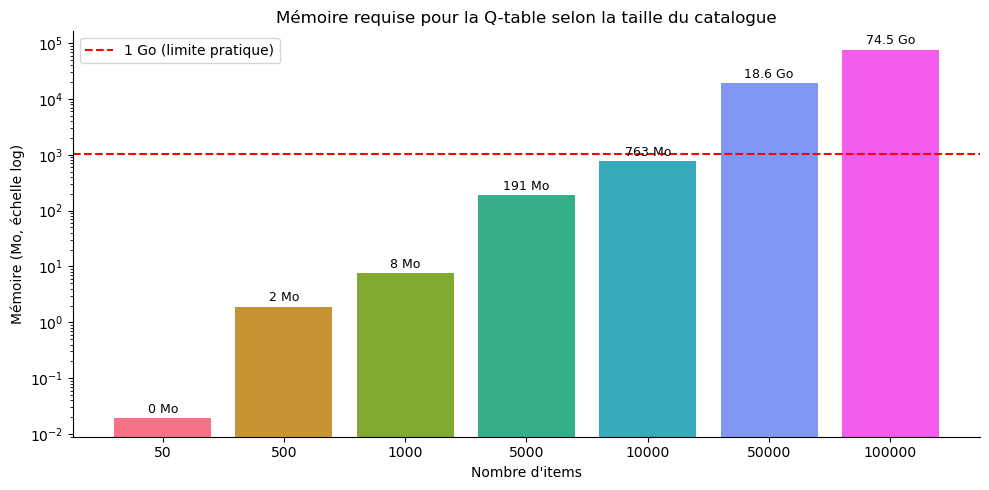

In [15]:
sizes  = [50, 500, 1000, 5000, 10000, 50000, 100000]
mem_mb = [n**2 * 8 / 1024**2 for n in sizes]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([str(n) for n in sizes], mem_mb, color=sns.color_palette('husl', len(sizes)))
for bar, mem in zip(bars, mem_mb):
    label = f'{mem:.0f} Mo' if mem < 1024 else f'{mem/1024:.1f} Go'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
            label, ha='center', va='bottom', fontsize=9)
ax.set_yscale('log')
ax.axhline(1024, color='red', linestyle='--', linewidth=1.5, label='1 Go (limite pratique)')
ax.set_title('Mémoire requise pour la Q-table selon la taille du catalogue')
ax.set_xlabel('Nombre d\'items')
ax.set_ylabel('Mémoire (Mo, échelle log)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/q_table_scalability.png', dpi=150)
plt.show()

---
## Phase 2 — Deep Q-Network (DQN) 🔜

---

## Phase 3 — GRU + DQN (Séquentiel) 🔜